In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/glaucoma_dataset/training_set",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 240 images belonging to 2 classes.


In [ ]:
val_data = test_datagen.flow_from_directory(
    "/content/drive/MyDrive/glaucoma_dataset/test_set",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 144 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 88s 11s/step - accuracy: 0.4333 - loss: 0.8131 - val_accuracy: 0.6806 - val_loss: 0.6875
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 45s 6s/step - accuracy: 0.5625 - loss: 0.6853 - val_accuracy: 0.3542 - val_loss: 0.7550
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 42s 5s/step - accuracy: 0.5833 - loss: 0.6771 - val_accuracy: 0.6806 - val_loss: 0.6395
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 44s 5s/step - accuracy: 0.6333 - loss: 0.6628 - val_accuracy: 0.7014 - val_loss: 0.5777
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 44s 6s/step - accuracy: 0.6958 - loss: 0.6127 - val_accuracy: 0.6597 - val_loss: 0.6051
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 42s 5s/step - accuracy: 0.7542 - loss: 0.5419 - val_accuracy: 0.7639 - val_loss: 0.4869
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 46s 6s/step - accuracy: 0.7792 - loss: 0.4645 - val_accuracy: 0.7431 - val_loss: 0.5239
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 46s 6s/step - accuracy: 0.7375 - loss: 0.5305 - val_accuracy: 0.8542 - val_loss: 0.4286
Epoch 9

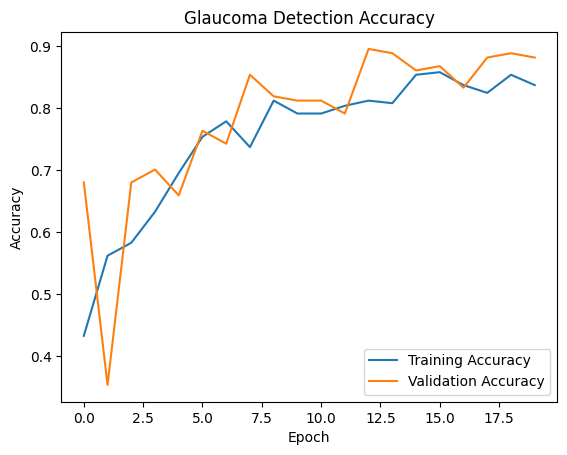

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Glaucoma Detection Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training Accuracy","Validation Accuracy"])

plt.show()

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Path to the image
img_path = "/content/drive/MyDrive/glaucoma_dataset/test_set/normal/r2_Im025.png"

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Convert image to array
img_array = image.img_to_array(img)

# Normalize and reshape
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Predict
prediction = model.predict(img_array)

# Result
if prediction[0][0] > 0.5:
    print("Prediction: Glaucoma")
else:
    print("Prediction: Normal Eye")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
Prediction: Normal Eye


In [ ]:
model.save("glaucoma_cnn_model.h5")

In [ ]:
loss, accuracy = model.evaluate(val_data)

print("Test Accuracy:", accuracy)


5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.8819 - loss: 0.3206
Test Accuracy: 0.8819444179534912


 ***Explainable AI(Grad-CAM - through saliency map
 )***

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

In [ ]:
img_path = "/content/drive/MyDrive/glaucoma_dataset/test_set/normal/r2_Im025.png"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
prediction = model.predict(img_array)

risk_score = prediction[0][0] * 100

print("Glaucoma Risk Score:", round(risk_score,2), "%")

if risk_score > 50:
    print("Diagnosis: Glaucoma Suspected")
else:
    print("Diagnosis: Normal Eye")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Glaucoma Risk Score: 31.84 %
Diagnosis: Normal Eye


In [ ]:
img_tensor = tf.convert_to_tensor(img_array)

with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    prediction = model(img_tensor)

grads = tape.gradient(prediction, img_tensor)

saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0]

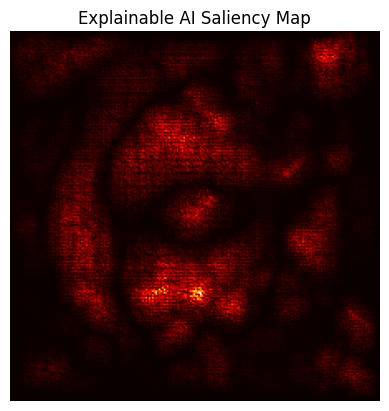

In [ ]:
plt.imshow(saliency, cmap="hot")
plt.title("Explainable AI Saliency Map")
plt.axis("off")
plt.show()

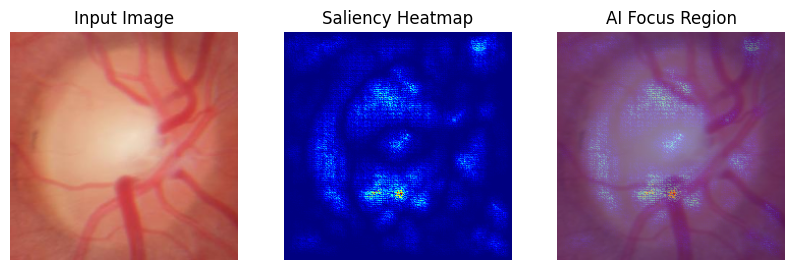

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# normalize saliency
saliency = np.abs(saliency)
saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min())

# resize saliency to image size
saliency_resized = cv2.resize(saliency, (224,224))

# convert to heatmap
heatmap = cv2.applyColorMap(np.uint8(255 * saliency_resized), cv2.COLORMAP_JET)

# load original image
original = cv2.imread(img_path)
original = cv2.resize(original,(224,224))

# overlay heatmap
overlay = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Saliency Heatmap")
plt.imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,3)
plt.title("AI Focus Region")
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

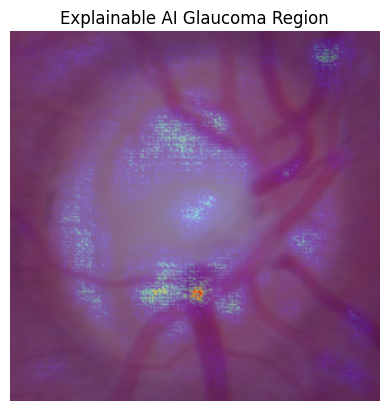

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# load original image
original = cv2.imread(img_path)

# resize saliency to match image
saliency_resized = cv2.resize(saliency,(original.shape[1],original.shape[0]))

# normalize
saliency_resized = (saliency_resized - saliency_resized.min()) / (saliency_resized.max() - saliency_resized.min())

# convert to heatmap
heatmap = cv2.applyColorMap(np.uint8(255*saliency_resized), cv2.COLORMAP_JET)

# overlay heatmap on image
overlay = cv2.addWeighted(original,0.6,heatmap,0.4,0)

# display
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Explainable AI Glaucoma Region")
plt.show()

**Interface**

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr
import cv2
import numpy as np

In [ ]:
def glaucoma_detection(img):

    img_resized = cv2.resize(img,(224,224))
    img_array = img_resized / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]

    risk_score = prediction * 100

    if risk_score > 50:
        diagnosis = "Glaucoma Suspected"
        confidence = "High"
    else:
        diagnosis = "Normal Eye"
        confidence = "Low"

    # -------- Explainable AI --------
    img_tensor = tf.convert_to_tensor(img_array)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        preds = model(img_tensor)
        loss = preds[:,0]

    grads = tape.gradient(loss, img_tensor)

    saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0].numpy()

    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min())

    heatmap = cv2.applyColorMap(np.uint8(255*saliency), cv2.COLORMAP_JET)

    heatmap = cv2.resize(heatmap,(224,224))

    overlay = cv2.addWeighted(img_resized,0.6,heatmap,0.4,0)

    report = f"""
## 🧠 AI Glaucoma Screening Report

Diagnosis: {diagnosis}

Risk Score: {risk_score:.2f} %

Confidence Level: {confidence}

⚠️ This AI system is designed for early glaucoma screening.
Clinical confirmation by an ophthalmologist is recommended.
"""

    return img_resized, heatmap, overlay, report

In [ ]:
interface = gr.Interface(
    fn=glaucoma_detection,
    inputs=gr.Image(type="numpy"),
    outputs=[
        gr.Image(label="Input Image"),
        gr.Image(label="Saliency Heatmap"),
        gr.Image(label="AI Focus Region"),
        gr.Markdown()
    ],
    title="Offline AI Glaucoma Detection System",
    description="Upload a retinal fundus image to detect glaucoma risk"
)

interface.launch()